# DPN for Binary Classification Classes (Expanded)

In [1]:
import json
import seaborn as sns
import warnings
import time
from pprint import pprint
import joblib
from tqdm import tqdm

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from CEval import CEval
import dice_ml
import shap

#. from module.dataload import DPN_data
#. from module.eda import EDA
#. from module.eda import EDAHelper

c:\Users\acbriza\anaconda3\envs\dpncf\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#. 
import sys 
sys.path.append('..')  

from module.backends.backend_adapter import get_dice_components
from module.models.optimizers import grid_search_cv_binary
from module.dataload import DPN_data
from module.eda import EDA


In [3]:
warnings.filterwarnings('ignore')
np.set_printoptions(precision=3)  # decimal places for outputs from numpy
pd.set_option("display.precision", 3)  # decimal places for outputs from pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

## Data Loading

In [5]:
D = DPN_data("../dataset/Sudoscan Working File with Stats.xlsx")
D.load(classification="binary")
D.load()

,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1,64.0,1,7.0,1.0,15.00,0,0,0,0,0,1,1,1,1,9.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0,1
1,0,59.0,1,1.0,0.0,5.60,1,0,0,0,0,0,0,0,0,4.0,19.41,52.30,14.21,61.90,49.3,3.55,14.34,10.55,42.50,19.54,55.7,15.09,61.20,48.3,3.30,13.29,9.48,43.3,39.0,5.0,38.0,28.0,50.0,39.0,0
2,0,64.0,1,11.0,1.0,7.50,1,0,0,0,0,1,1,1,1,5.0,0.00,0.00,0.00,0.00,35.9,4.35,1.83,1.29,54.40,0.00,0.0,0.00,0.00,36.2,4.70,2.40,1.92,54.7,65.0,14.0,79.0,1.0,50.0,33.0,1
3,0,53.0,1,10.0,1.0,7.60,1,0,1,0,0,1,0,0,0,8.0,7.86,46.70,7.07,42.50,40.4,4.30,6.08,4.20,51.00,8.98,48.7,8.08,42.70,40.0,4.25,7.81,6.18,50.9,43.0,10.0,49.0,5.0,57.0,33.0,1
4,1,57.0,0,5.0,1.0,14.40,0,0,0,0,0,1,0,1,1,1.0,4.19,41.90,3.70,38.20,38.5,4.50,8.89,6.88,48.30,5.36,45.5,4.42,39.50,38.3,4.00,10.29,8.82,49.9,54.0,3.0,63.0,0.0,54.0,36.0,1
5,0,20.0,1,2.0,1.0,7.80,0,0,0,0,0,0,0,1,0,0.0,26.55,47.40,14.42,49.60,45.4,3.75,17.17,11.36,49.40,32.17,46.3,16.06,44.10,42.2,3.35,21.26,15.37,50.3,67.0,4.0,80.0,4.0,99.0,0.0,0
6,0,69.0,0,0.0,0.0,8.00,1,0,1,0,0,0,1,0,0,1.0,11.40,51.70,17.16,54.50,44.7,3.20,13.69,10.06,46.40,12.56,48.7,13.61,53.40,48.4,3.70,13.51,8.37,46.6,74.0,1.0,77.0,6.0,49.0,33.0,0
7,0,60.0,0,2.0,0.0,5.80,1,0,0,0,0,1,0,0,0,5.0,19.46,49.60,7.46,49.60,42.3,3.30,13.74,10.44,47.00,19.50,46.2,9.84,40.10,43.8,3.40,13.55,10.87,46.9,63.0,4.0,65.0,11.0,54.0,29.0,0
8,1,62.0,0,0.0,1.0,14.36,0,0,0,0,0,1,1,1,0,3.0,8.36,45.10,0.00,0.00,36.4,3.75,9.20,6.53,56.10,7.58,44.6,0.00,0.00,35.7,3.95,9.42,7.25,57.2,72.0,2.0,61.0,19.0,56.0,31.0,1
9,0,44.0,1,17.0,0.0,7.01,0,0,0,0,0,1,1,1,1,10.0,1.13,46.90,0.00,0.00,36.6,5.10,4.22,2.52,56.60,1.26,42.4,0.00,0.00,35.6,4.75,4.02,2.09,55.4,19.0,10.0,84.0,1.0,64.0,18.0,1


Binary Classification Classes:  ['Negative', 'Possible', 'Probable'] vs 'Confirmed'


In [6]:
dfdpn = D.df
data_cols = dfdpn.drop(D.non_data_cols, axis=1, errors="ignore").columns
len(data_cols), data_cols

(40,
 Index(['SEX', 'AGE', 'SUBJ', 'DM_DUR', 'INSULIN', 'HBA1C', 'HPN', 'PAOD',
        'DSLPDMIA', 'CKD', 'GBS', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR',
        'MNSI', 'SSA_L', 'SSC_L', 'SPSA_L', 'SPSC_L', 'MCV_L', 'DL_L',
        'CMAPANK_L', 'CMAPKNE_L', 'FWAVE_L', 'SSA_R', 'SSC_R', 'SPSA_R',
        'SPSC_R', 'MCV_R', 'DL_R', 'CMAPANK_R', 'CMAPKNE_R', 'FWAVE_R',
        'FEET_MEAN_ESC', 'FEET_PCT_ASYM', 'HAND_MEAN_ESC', 'HAND_PCT_ASYM',
        'NS', 'CAS'],
       dtype='object'))

### Data Inspection

In [7]:
X = dfdpn[data_cols]
y = dfdpn['Confirmed_Binary_DPN']
X.shape, y.shape

((190, 40), (190,))

### Set Global Variables

In [8]:
test_size = 0.25
verbosity = 1

### Full Features

In [9]:
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

# Classical ML models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Gradient boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [10]:
def get_column_types(X):
    """
    Returns list of binary and continuous column names/indices.
    Works for both Pandas DataFrames and Numpy Arrays.
    """
    # Convert to DataFrame if it's a numpy array for easier handling
    if isinstance(X, np.ndarray):
        df = pd.DataFrame(X)
    else:
        df = X

    binary_cols = []
    continuous_cols = []

    for col in df.columns:
        # Check if column has only 0s and 1s (ignoring NaNs)
        unique_vals = df[col].dropna().unique()
        if set(unique_vals).issubset({0, 1, 0.0, 1.0}):
            binary_cols.append(col)
        else:
            continuous_cols.append(col)
            
    return binary_cols, continuous_cols

In [11]:
def build_smart_pipeline(model_name, model_instance, X_train):
    """
    Builds a pipeline that:
    1. Leaves binary columns alone ('passthrough').
    2. Scales continuous columns based on what the model needs.
    """

    # Detect columns based on the training data provided
    binary_cols, continuous_cols = get_column_types(X_train)

    # Define Model Groups
    NEEDS_STANDARD = ["RBF SVM", "Linear SVM", "Naive Bayes", "Logistic Regression", "LDA", "QDA"]
    NEEDS_MINMAX = ['kNN', ]
    
    # Select the Scaler
    scaler = None
    if model_name in NEEDS_STANDARD:
        scaler = StandardScaler()
        scale_type = "StandardScaler"
    elif model_name in NEEDS_MINMAX:
        scaler = MinMaxScaler()
        scale_type = "MinMaxScaler"
    else:
        scaler = None # e.g. Trees don't need scaling
        scale_type = "None"

    # Build the Preprocessor
    if scaler:
        # If scaling is needed, apply it ONLY to continuous cols
        preprocessor = ColumnTransformer(
            transformers=[
                ('scale_continuous', scaler, continuous_cols),
                ('keep_binary', 'passthrough', binary_cols)
            ],
            # remainder='drop' # safety: drop anything else not accounted for
        )
        steps = [('preprocessor', preprocessor), ('model', model_instance)]
        print(f"⚙️ {model_name}: Scaling continuous cols with {scale_type}")
    else:
        # If no scaling needed (e.g. Random Forest), skip preprocessor entirely
        steps = [('model', model_instance)]
        print(f"⏩ {model_name}: No scaling applied.")

    return Pipeline(steps)

In [12]:
# Define Models
models = {
    "Naive": DummyClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=500),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "SGDClassifier": SGDClassifier(max_iter=1000, tol=1e-3),

    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0),

    "kNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),

    "Linear SVM": SVC(kernel="linear", probability=True),
    "RBF SVM": SVC(kernel="rbf", probability=True),
}

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, make_scorer
)

# Custom Youden Index scorer
def youden_index_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return sensitivity + specificity - 1

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

youden_scorer = make_scorer(youden_index_score, greater_is_better=True)
specificity_scorer = make_scorer(specificity_score)

def benchmark_models(X, y, cv_splits=5, n_repeats=10, random_state=27):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    rcv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=n_repeats, random_state=random_state)
    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "youden": youden_scorer,
        "specificity": specificity_scorer
    }

    results = []
    for name, model in models.items():
        pipe = build_smart_pipeline(name, model, X)
        #scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1, error_score="raise")
        scores = cross_validate(pipe, X, y, cv=rcv, scoring=scoring, n_jobs=-1, error_score="raise")
        algo_results = {
            "Accuracy": scores["test_accuracy"],
            "Precision": scores["test_precision"],
            "Sensitivity": scores["test_recall"],
            "Specificity": scores["test_specificity"],
            "Youden Index": scores["test_youden"],
            "F1": scores["test_f1"],
            "ROC-AUC": scores["test_roc_auc"],
        }
        results.append({
            "Model": name,
            "Scores" : pd.DataFrame(algo_results)
        })

    # sort by Youden Index instead of ROC-AUC
    return results


----

## Iterative Group Feature Elimination

In [14]:
N_REPEATS = 2
model_metrics = {}  # key: dataset code, value: perfomance metrics of all algorithms 
youden_means = {}    # key: dataset code, value: mean of the perfomance metrics of all algorithms
youden_scores  = {} # key: dataset code, value: list of youden cv scores algorithms

### All Features

In [15]:
model_metrics['all'] = benchmark_models(X, y, n_repeats=N_REPEATS)

⏩ Naive: No scaling applied.
⚙️ Logistic Regression: Scaling continuous cols with StandardScaler
⚙️ LDA: Scaling continuous cols with StandardScaler
⚙️ QDA: Scaling continuous cols with StandardScaler
⏩ SGDClassifier: No scaling applied.
⏩ Decision Tree: No scaling applied.
⏩ Random Forest: No scaling applied.
⏩ Extra Trees: No scaling applied.
⏩ Gradient Boosting: No scaling applied.
⏩ XGBoost: No scaling applied.
⏩ LightGBM: No scaling applied.
⏩ CatBoost: No scaling applied.
⚙️ kNN: Scaling continuous cols with MinMaxScaler
⚙️ Naive Bayes: Scaling continuous cols with StandardScaler
⚙️ Linear SVM: Scaling continuous cols with StandardScaler
⚙️ RBF SVM: Scaling continuous cols with StandardScaler


In [16]:
model_metrics['all'] # list of dictionary with 2 keys, model and scores (a dataframe)

[{'Model': 'Naive',
  'Scores':    Accuracy  Precision  Sensitivity  Specificity  Youden Index     F1  ROC-AUC
  0     0.684      0.684          1.0          0.0           0.0  0.812      0.5
  1     0.684      0.684          1.0          0.0           0.0  0.812      0.5
  2     0.684      0.684          1.0          0.0           0.0  0.812      0.5
  3     0.684      0.684          1.0          0.0           0.0  0.812      0.5
  4     0.684      0.684          1.0          0.0           0.0  0.812      0.5
  5     0.684      0.684          1.0          0.0           0.0  0.812      0.5
  6     0.684      0.684          1.0          0.0           0.0  0.812      0.5
  7     0.684      0.684          1.0          0.0           0.0  0.812      0.5
  8     0.684      0.684          1.0          0.0           0.0  0.812      0.5
  9     0.684      0.684          1.0          0.0           0.0  0.812      0.5},
 {'Model': 'Logistic Regression',
  'Scores':    Accuracy  Precision  Sensiti

In [17]:
model_metrics['all'][0]['Scores']

,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
0,0.684,0.684,1.0,0.0,0.0,0.812,0.5
1,0.684,0.684,1.0,0.0,0.0,0.812,0.5
2,0.684,0.684,1.0,0.0,0.0,0.812,0.5
3,0.684,0.684,1.0,0.0,0.0,0.812,0.5
4,0.684,0.684,1.0,0.0,0.0,0.812,0.5
5,0.684,0.684,1.0,0.0,0.0,0.812,0.5
6,0.684,0.684,1.0,0.0,0.0,0.812,0.5
7,0.684,0.684,1.0,0.0,0.0,0.812,0.5
8,0.684,0.684,1.0,0.0,0.0,0.812,0.5
9,0.684,0.684,1.0,0.0,0.0,0.812,0.5


In [18]:
def calculate_youden_mean(algo_metrics):
    df_means = pd.concat(
        [pd.DataFrame({df['Model']: df['Scores'].mean()}) for df in algo_metrics],
        axis=1
        ).T.sort_values(by="Youden Index", ascending=False)
    return df_means

youden_means['all'] = calculate_youden_mean(model_metrics['all'])
youden_means['all']

,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
CatBoost,0.950,0.966,0.962,0.925,0.887,0.963,0.977
Random Forest,0.947,0.959,0.965,0.908,0.874,0.962,0.976
LightGBM,0.942,0.955,0.962,0.900,0.862,0.958,0.978
Gradient Boosting,0.939,0.948,0.965,0.883,0.849,0.956,0.974
XGBoost,0.934,0.951,0.954,0.892,0.846,0.952,0.972
Extra Trees,0.926,0.943,0.950,0.875,0.825,0.946,0.979
Decision Tree,0.889,0.918,0.923,0.817,0.740,0.920,0.870
RBF SVM,0.889,0.909,0.935,0.792,0.726,0.921,0.941
Naive Bayes,0.824,0.958,0.777,0.925,0.702,0.855,0.920
Logistic Regression,0.871,0.899,0.919,0.767,0.686,0.907,0.921


In [24]:
# just get the list of youden scores
dfy = pd.concat(
    [pd.DataFrame({df['Model']: df['Scores']['Youden Index']}) for df in model_metrics['all']],
    axis=1
    )
youden_scores['all'] = dfy[youden_means['all'].T.columns.tolist()] # sort columns by youden means
youden_scores['all'] 

,CatBoost,Random Forest,LightGBM,Gradient Boosting,XGBoost,Extra Trees,Decision Tree,RBF SVM,Naive Bayes,Logistic Regression,Linear SVM,LDA,SGDClassifier,kNN,QDA,Naive
0,1.000,0.917,0.833,0.833,0.917,0.917,0.840,0.840,0.801,0.756,0.795,0.590,0.763,0.513,-0.077,0.0
1,0.756,0.801,0.756,0.673,0.635,0.718,0.635,0.673,0.808,0.551,0.635,0.551,0.545,0.712,0.481,0.0
2,0.962,0.962,0.962,0.962,0.962,0.756,0.801,0.756,0.532,0.756,0.718,0.635,0.801,0.551,0.237,0.0
3,0.795,0.833,0.833,0.756,0.756,0.833,0.628,0.628,0.679,0.628,0.506,0.474,0.167,0.462,-0.109,0.0
4,0.878,0.795,0.878,0.962,0.795,0.795,0.712,0.795,0.647,0.795,0.756,0.718,0.417,0.468,0.000,0.0
5,0.878,0.878,0.840,0.756,0.756,0.795,0.718,0.628,0.724,0.628,0.679,0.551,0.590,0.423,0.173,0.0
6,1.000,1.000,1.000,1.000,1.000,0.878,0.885,0.878,0.769,0.795,0.712,0.628,0.795,0.423,0.218,0.0
7,0.917,0.833,0.917,0.917,0.917,0.878,0.673,0.590,0.647,0.506,0.506,0.391,0.250,0.551,0.045,0.0
8,0.923,0.962,0.840,0.917,0.923,0.923,0.833,0.801,0.609,0.769,0.603,0.519,0.468,0.558,0.314,0.0
9,0.756,0.756,0.756,0.712,0.795,0.756,0.673,0.673,0.801,0.673,0.673,0.673,0.756,0.712,0.128,0.0


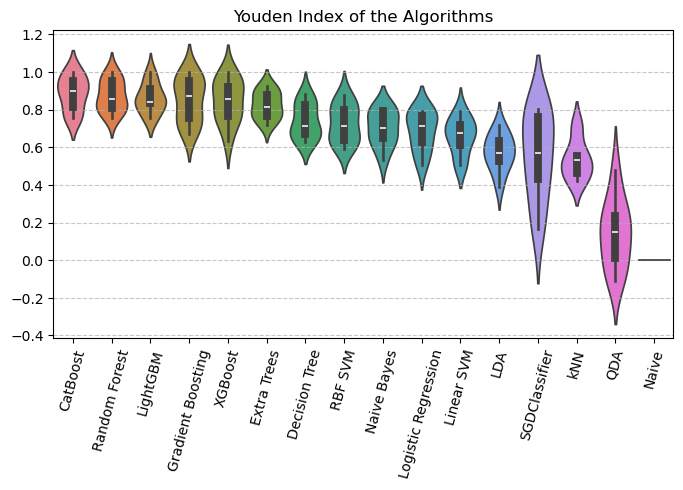

In [26]:
# plot a violin plot
def plot_youden_scores(yscores):
    plt.figure(figsize=(8, 4))
    sns.violinplot(data=yscores)
    plt.title('Youden Index of the Algorithms')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=75)
    plt.show()

plot_youden_scores(youden_scores['all'])

In [21]:
# save results 
joblib.dump(model_metrics, r"outputs\model_metrics.pkl")
joblib.dump(youden_means, r"outputs\youden_means.pkl")
joblib.dump(youden_scores, r"outputs\youden_scores.pkl")

['outputs\\youden_scores.pkl']

In [22]:
# Verify saved results
loaded_model_metrics = joblib.load(r"outputs\model_metrics.pkl")
calculate_youden_mean(loaded_model_metrics['all'])

,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
CatBoost,0.950,0.966,0.962,0.925,0.887,0.963,0.977
Random Forest,0.947,0.959,0.965,0.908,0.874,0.962,0.976
LightGBM,0.942,0.955,0.962,0.900,0.862,0.958,0.978
Gradient Boosting,0.939,0.948,0.965,0.883,0.849,0.956,0.974
XGBoost,0.934,0.951,0.954,0.892,0.846,0.952,0.972
Extra Trees,0.926,0.943,0.950,0.875,0.825,0.946,0.979
Decision Tree,0.889,0.918,0.923,0.817,0.740,0.920,0.870
RBF SVM,0.889,0.909,0.935,0.792,0.726,0.921,0.941
Naive Bayes,0.824,0.958,0.777,0.925,0.702,0.855,0.920
Logistic Regression,0.871,0.899,0.919,0.767,0.686,0.907,0.921


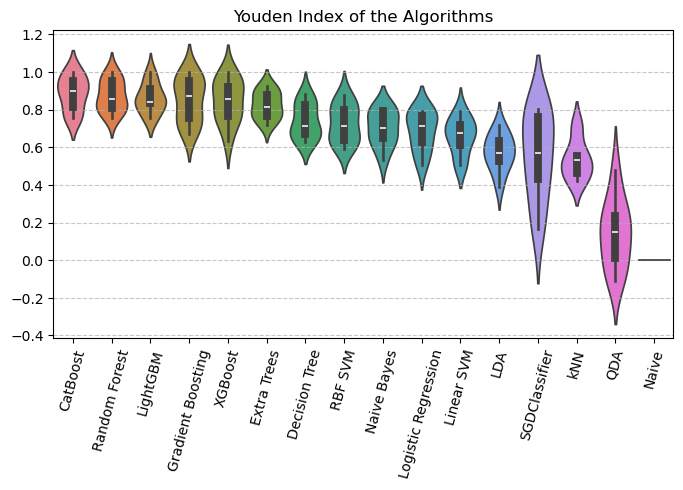

In [29]:
loaded_youden_scores = joblib.load(r"outputs\youden_scores.pkl")
plot_youden_scores(loaded_youden_scores['all'])

### No Collinear Features

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Example: df is your DataFrame with predictors
X2 = X.copy()

# Add constant term (intercept) for statsmodels
X2 = add_constant(X2)

# Compute VIF for each column
vif_data = pd.DataFrame()
vif_data["feature"] = X2.columns
vif_data["VIF"] = [variance_inflation_factor(X2.values, i) 
                   for i in range(X2.shape[1])]
high_vif = vif_data[vif_data["VIF"]>5]
print(high_vif)

In [ ]:
# drop these features which seem to be collinear
high_vif_features = high_vif.feature.values.tolist()[1:]
high_vif_features

In [ ]:
Xnc = X.drop(columns=high_vif_features) #X no collinear
print(Xnc.shape)
Xnc.head(2)

In [ ]:
dfnc_means = benchmark_models(Xnc, y, n_repeats=N_REPEATS)

In [ ]:
dfnc_means = calculate_youden_mean(dfnc_results)
dfnc_means

In [ ]:
joblib.dump(dfnc_results, r"outputs\nocollinear_features\model_results-2026-01-07.pkl")

 -----

### No NCS

In [ ]:
Xnncs = X.drop(columns=D.ncs_cols) #X no nerve conduction studies
print(D.ncs_cols)
Xnncs.shape, Xnncs.head(2)

In [ ]:
dfnncs_results = benchmark_models(Xnncs, y, n_repeats=N_REPEATS)

In [ ]:
dfnncs_means = calculate_youden_mean(dfnncs_results)
dfnncs_means

In [ ]:
joblib.dump(dfnncs_results, r"outputs\noNCS_features\model_results-2026-01-07.pkl")

 -----

### No Sudoscan Features

In [ ]:
Xnsudo = X.drop(columns=D.sudo_cols) #X no nerve conduction studies
print(D.sudo_cols)
print(Xnsudo.shape)
Xnsudo.head(2)

In [ ]:
dfnsudo_results = benchmark_models(Xnsudo, y, n_repeats=N_REPEATS)

In [ ]:
dfnsudo_means = calculate_youden_mean(dfnsudo_results)
dfnsudo_means

In [ ]:
joblib.dump(dfnsudo_results, r"outputs\noSUDO_features\model_results-2026-01-07.pkl")

 -----

### No Neuro Features

In [ ]:
Xnneuro = X.drop(columns=D.neuro_cols) #X no neuro columns
print(D.neuro_cols)
print(Xnneuro.shape) 
Xnneuro.head(2)

In [ ]:
dfnneuro_results = benchmark_models(Xnneuro, y, n_repeats=N_REPEATS)

In [ ]:
dfnneuro_means = calculate_youden_mean(dfnneuro_results)
dfnneuro_means

In [ ]:
joblib.dump(dfnneuro_results, r"outputs\noNEURO_features\model_results-2026-01-07.pkl")

 -----

### No Commorbidity Features

In [ ]:
Xncom = X.drop(columns=D.comorbidity_cols) #X no neuro columns
print(D.comorbidity_cols)
print(Xncom.shape)
Xncom.head(2)

In [ ]:
dfncom_results = benchmark_models(Xncom, y, n_repeats=N_REPEATS)

In [ ]:
dfncom_means = calculate_youden_mean(dfncom_results)
dfncom_means

In [ ]:
joblib.dump(dfncom_results, r"outputs\noCOM_features\model_results-2026-01-07.pkl")

 -----

### No MNSI Feature

In [ ]:
Xnmnsi = X.drop(columns=D.mnsi_col) #X no neuro columns
print(D.mnsi_col)
print(Xnmnsi.shape)
Xnmnsi.head(2)

In [ ]:
dfnmnsi_results = benchmark_models(Xnmnsi, y, n_repeats=2)

In [ ]:
dfnmnsi_means = calculate_youden_mean(dfnmnsi_results)
dfnmnsi_means

In [ ]:
joblib.dump(dfnmnsi_results, r"outputs\noMNSI_feature\model_results-2026-01-07.pkl")

 -----

### No Profile Feature

In [ ]:
Xnprof = X.drop(columns=D.profile_cols) #X no neuro columns
print(D.profile_cols)
print(Xnprof.shape) 
Xnprof.head(2)

In [ ]:
dfnprof_results = benchmark_models(Xnprof, y, n_repeats=2)

In [ ]:
dfnprof_means = calculate_youden_mean(dfnprof_results)
dfnprof_means

In [ ]:
joblib.dump(dfnprof_results, r"outputs\noPROF_features\model_results-2026-01-07.pkl")

 -----

### Summary of Iterative Group Feature Elimination

In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# Suppose you have several results DataFrames
# e.g., results_df1, results_df2, results_df3

dataframes = {
    "All": dfall_means,
    "NoSUDO": dfnsudo_means,
    "NoProf": dfnprof_means,
    "NoCom": dfncom_means,
    "NoNeuro": dfnneuro_means,
    "NoMNSI": dfnmnsi_means,
    "NoCol": dfnc_means,
    "NoNCS": dfnncs_means,
}

# Collect the 'Youden' column from each dataframe
youden_table = pd.DataFrame()

for name, df in dataframes.items():
    youden_table[name] = df["Youden Index"]
k=5
topk_avg = youden_table.apply(lambda col: col.nlargest(k).mean())
youden_table.loc[f"Top {k} Avg"] = topk_avg

youden_table['mean'] = youden_table.mean(axis=1)

# Reorder rows if needed
# youden_table = youden_table.reindex(sorted(youden_table.index))

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(youden_table, annot=True, cmap="coolwarm", center=0)
plt.title("Youden Index Across Models and Datasets")
plt.ylabel("Model")
plt.xlabel("Dataset")
plt.show()

## NCS Only

In [ ]:
Xncs = X[D.ncs_cols] #X nerve conduction studies
print(D.ncs_cols)
print(Xncs.shape) 
Xncs.head(2)

In [ ]:
dfncs_results = benchmark_models(Xncs, y)
dfncs_results

In [ ]:
dfncs_means = calculate_youden_mean(dfncs_results)
dfncs_means

In [ ]:
joblib.dump(dfnc_results, r"outputs\NCS_features\model_results-2026-01-07.pkl")

## Sudoscan Only Only

In [ ]:
Xsudo = X[D.sudo_cols] 
print(Xsudo.shape) 
Xsudo.head(2)

In [ ]:
dfsudo_results = benchmark_models(Xsudo, y)
dfsudo_results

In [ ]:
dfsudo_means = calculate_youden_mean(dfsudo_results)
dfsudo_means

In [ ]:
joblib.dump(dfsudo_results, r"outputs\sudo_features\model_results-2026-01-07.pkl")

In [ ]:
dataframes = {
    "All": dfall_means,
    "NoSUDO": dfnsudo_means,
    "NoProf": dfnprof_means,
    "NoCom": dfncom_means,
    "NoNeuro": dfnneuro_means,
    "NoMNSI": dfnmnsi_means,
    "NoCol": dfnc_means,
    "NoNCS": dfnncs_means,
    "NCS": dfncs_means,
    "Sudo": dfsudo_means,
}


# Collect the 'Youden' column from each dataframe
youden_table = pd.DataFrame()

for name, df in dataframes.items():
    youden_table[name] = df["Youden Index"]

k=6
topk_avg = youden_table.apply(lambda col: col.nlargest(k).mean())
youden_table.loc[f"Top {k} Avg"] = topk_avg

#youden_table['mean'] = youden_table.mean(axis=1)

# Reorder rows if needed
# youden_table = youden_table.reindex(sorted(youden_table.index))

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(youden_table, annot=True, cmap="coolwarm", center=0)
plt.title("Youden Index Across Models and Datasets")
plt.ylabel("Model")
plt.xlabel("Dataset")
plt.savefig('outputs/model_cv5_summary.png')
plt.show()


 -----

## Optuna: Bayesian Optmization of Best Binary Classifier (RF)

In [ ]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.datasets import load_breast_cancer

# 1. Load data (Breast Cancer dataset is a good example for binary classification)
data = load_breast_cancer()
X, y = data.data, data.target

def objective(trial):
    # 2. Define the search space
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    
    # 3. Instantiate the Model
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        n_jobs=-1,        # Use all CPU cores for the Random Forest training
        random_state=42   # Fix seed for the Random Forest initialization
    )
    
    # 4. Define StratifiedKFold
    # IMPORTANT: shuffle=True with a fixed random_state ensures 
    # the same folds are used for every single trial.
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # 5. Run Cross-Validation
    # Pass the cv_strategy object to the cv argument
    scores = cross_val_score(clf, X, y, cv=cv_strategy, scoring=youden_scorer)
    
    # 6. Return the mean accuracy
    return scores.mean()

# 7. Run Optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=3)

print(f"Best Performance: {study.best_value}")
print(f"Best Params: {study.best_params}")

In [ ]:
import optuna.visualization as vis
fig = vis.plot_parallel_coordinate(study)
fig.show()

## BayesSearchCV: Bayesian Optmization of Best Binary Classifier (RF)

In [ ]:
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

# Define the model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Define the hyperparameter search space
param_space = {
    "n_estimators": Integer(50, 500),
    "max_depth": Integer(2, 30),
    "min_samples_split": Integer(2, 10),
    "min_samples_leaf": Integer(1, 10),
    "criterion": Categorical(["gini", "entropy"]),
    "max_features": Categorical(["sqrt", "log2", 0.8]),
    "bootstrap": Categorical([True, False]),
    "class_weight": Categorical([None, "balanced", "balanced_subsample"])
}

# Bayesian Optimization with cross-validation
opt = BayesSearchCV(
    estimator=rf,
    search_spaces=param_space,
    n_iter=100,                # number of parameter settings to try
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=27),
    scoring="roc_auc",        # or "youden", "f1", etc.
    n_jobs=-1,
    random_state=42,
    verbose=0
)

opt.fit(X, y)

print("Best parameters:", opt.best_params_)
print("Best ROC-AUC:", opt.best_score_)


In [ ]:
best_model = opt.best_estimator_

 -----

## Model Evaluation Preparation

#### Train Test Split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size, random_state=0, stratify=y)

#### Evaluate the Model

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall (Sensitivity)": recall_score(y_test, y_pred),
        "Specificity": specificity_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
        "Youden Index": youden_index_score(y_test, y_pred)
    }
    return pd.Series(metrics)

## Model Evaluation

In [ ]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_val)
y_proba = best_model.predict_proba(X_val)[:, 1]
results = evaluate_model(best_model, X_val, y_val)
print(results)

#### Saving the Optimized Model

In [ ]:
def save_optimized_results(name, best_params, best_score, optimized_model, optimized_model_metrics):
    model_results = { 
        "name" : name,
        "best_params": best_params, 
        "best_score": best_score, 
        "optimized_model": optimized_model, 
        "optimized_model_metrics": optimized_model_metrics
    }
    joblib.dump(model_results, rf"outputs\all_features\{name}.pkl")

In [ ]:
save_optimized_results("random_forest", opt.best_params_, opt.best_score_, best_model, results)

## Post Optimization Analysis from Saved File

#### Load variables from pickle file

In [ ]:
rf_optimized_results = joblib.load(rf"outputs\all_features\random_forest.pkl")

model_name = rf_optimized_results["name"]
best_params = rf_optimized_results["best_params"]
best_score = rf_optimized_results["best_score"]  
optimized_model = rf_optimized_results["optimized_model"] 
optimized_model_metrics = rf_optimized_results["optimized_model_metrics"]

optimized_model_metrics

In [ ]:
# optimized_model.fit(X_train, y_train) # no longer needed
y_pred = optimized_model.predict(X_val)
y_proba = optimized_model.predict_proba(X_val)[:, 1]
results = evaluate_model(optimized_model, X_val, y_val)
print(results)

#### Define Features Group Color Map

In [ ]:
import matplotlib.patches as mpatches

palette = {
    'Teal': '#8DD3C7', 
    'Yellow': '#FFFFB3', 
    'Lavender': '#BEBADA', 
    'Coral': '#FB8072', 
    'Blue': '#80B1D3', 
    'Orange': '#FDB462', 
    'Green': '#B3DE69', 
    'Pink': '#FCCDE5', 
    'Purple': '#BC80BD', 
    'Gray': '#D9D9D9', 
    'Red': '#E41A1C' 
}

COLOR_GROUP_MAP = {
    'Nerve Conduction Studies': palette['Blue'],
    'Sudoscan': palette['Orange'],
    'Profile': palette['Teal'],
    'Comorbidities': palette['Red'],
    'Neurology Examination': palette['Pink'],
    'MNSI': palette['Green'],
    # 'Others': palette['Gray']
}

def get_colors(labels):
    # D is assumed to be available in the scope (e.g., imported module or class instance)
    return [
        COLOR_GROUP_MAP['Nerve Conduction Studies']  if label in D.ncs_cols else 
        COLOR_GROUP_MAP['Sudoscan'] if label in D.sudo_cols else 
        COLOR_GROUP_MAP['Profile'] if label in D.profile_cols else 
        COLOR_GROUP_MAP['Comorbidities'] if label in D.comorbidity_cols else # Assuming 'Red' is the intended color
        COLOR_GROUP_MAP['Neurology Examination'] if label in D.neuro_cols else 
        COLOR_GROUP_MAP['MNSI'] if label in D.mnsi_col else 
        palette['Gray']
        for label in labels
    ]

#### Feature Importance

In [ ]:
importances = optimized_model.feature_importances_
feature_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)
feature_importances_trimmed = feature_importances[feature_importances>0.001]
feature_importances_trimmed[:5]

In [ ]:
plt.figure(figsize=(10,8))
ax = feature_importances_trimmed.plot(
    kind='barh',
    color = get_colors(feature_importances_trimmed.index.to_list())
)

plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")

# --- Legend Addition ---
legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in COLOR_GROUP_MAP.items()
]

# Add the legend to the plot
ax.legend(
    handles=legend_handles, 
    title="Feature Groups", 
    loc='best' # Adjust location as needed (e.g., 'best', 'outside')
)
plt.savefig(r'outputs\figures\'rf_features_importances.png')
plt.show()

#### ROC Curve

In [ ]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_val, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chance level')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
plt.savefig("outputs/figures/rf_roc.png") 

### DCA

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def decision_curve_analysis(model, X, y, thresholds=None, label="Model"):
    """
    Perform Decision Curve Analysis (DCA) for a trained classifier.

    Parameters:
    -----------
    model : sklearn-like estimator
        Must have a predict_proba method.
    X : array-like
        Feature matrix (test set).
    y : array-like
        True binary labels.
    thresholds : array-like, optional
        List or array of thresholds to evaluate. Defaults to np.linspace(0.01, 0.99, 50).
    label : str, optional
        Label for the model curve.

    Returns:
    --------
    thresholds : np.array
        Threshold probabilities.
    net_benefits : list
        Net benefit values for the model.
    """

    # Default thresholds
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 50)

    # Get predicted probabilities
    y_pred_prob = model.predict_proba(X)[:, 1]

    N = len(y)
    net_benefits = []

    for pt in thresholds:
        y_pred = (y_pred_prob >= pt).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

        net_benefit = (tp / N) - (fp / N) * (pt / (1 - pt))
        net_benefits.append(net_benefit)

    # Plotting
    plt.plot(thresholds, net_benefits, label=label, linewidth=2)
    plt.plot(thresholds, [0]*len(thresholds), linestyle="--", label="Treat None")
    plt.plot(thresholds, thresholds, linestyle="--", label="Treat All")  # Simplified version

    plt.xlabel("Threshold Probability")
    plt.ylabel("Net Benefit")
    plt.title("Decision Curve Analysis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

    return thresholds, net_benefits


In [ ]:
thresholds, nb = decision_curve_analysis(optimized_model, X_val, y_val, label="Random Forest")

In [ ]:
fpr, tpr, thresholds = roc_curve(y_val, y_proba)
youden_index = tpr - fpr
best_threshold = thresholds[youden_index.argmax()]
print("Best threshold:", best_threshold)

### Evaluate Best Threshold for Youden Index

In [ ]:
def evaluate_model_thresholded(model, X_test, y_test, threshold):
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    y_pred = (y_proba >= threshold).astype(int)
    
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall (Sensitivity)": recall_score(y_test, y_pred),
        "Specificity": specificity_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
        "Youden Index": youden_index_score(y_test, y_pred)
    }
    return pd.Series(metrics)

thresholds = np.arange(0.1, 0.85, 0.05)
youdens = [evaluate_model_thresholded(optimized_model, X_val, y_val, k)['Youden Index'] for k in thresholds]

In [ ]:
plt.plot(thresholds, youdens)
plt.show()

## SHAP Analysis

In [ ]:
# Define a simple predict function for the current model
# This closure ensures 'model' refers to the correct model in each iteration
def current_model_predict(X):
    # For classifiers, .predict_proba is often preferred for SHAP for better interpretability
    # especially for multi-class, but .predict is also valid.
    # We'll use .predict here as per your original request, but it's good to note.
    return optimized_model.predict_proba(X)[:, 1] #.
    #. return optimized_model.predict(X) 

# Use a masker: your input DataFrame
#. Don't use a masker so we preserve correlations
#. masker = shap.maskers.Independent(X_val)

# Create explainer with custom predict function
# Specify the masker for consistency
#. explainer = shap.Explainer(current_model_predict, masker=masker)

#. use x_val directly
explainer = shap.Explainer(current_model_predict, X_val) 

# Compute SHAP values
shap_values = explainer(X_val)

In [ ]:
# Plot the summary plot for the current model
# show=False prevents immediate display, allowing title to be set
plt.figure(figsize=(5,7))
shap.summary_plot(shap_values, X_val, show=False, plot_type="bar", plot_size=None)
plt.title(f"SHAP Values for {model_name.replace('_', ' ').title()}")
plt.tight_layout() # Adjust layout to prevent title overlap
plt.show() # Display the plot for the current model

In [ ]:

# Assuming 'D' is an available object with the feature lists (e.g., D.ncs_cols)
# Assuming 'shap_values' and 'X_val' are defined.

plt.figure(figsize=(5, 7))

# 3.1 Generate the SHAP summary plot (bar type)
# We set show=False to prevent Matplotlib from displaying it immediately
shap.summary_plot(shap_values, X_val, show=False, plot_type="bar", plot_size=None)

# 3.2 Get the current Axes object (which contains the plot)
# This is usually the first (and only) Axes created by the shap plot.
ax = plt.gca()

# 3.3 Identify the features and assign colors
# The SHAP bar plot automatically orders features by importance (the Y-axis labels)
feature_names = [label.get_text() for label in ax.get_yticklabels()]
bar_colors = get_colors(feature_names)

# 3.4 Manually re-color the bars 
# The bars are the first container of rectangles in the axes.
# They are typically stored in ax.containers[0]
for bar, color in zip(ax.containers[0].patches, bar_colors):
    bar.set_color(color)

# 3.5 Add Custom Legend
legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in COLOR_GROUP_MAP.items()
]

# Set the title first (from your original prompt)
plt.title("SHAP Values Feature Importance")

# Add the legend to the plot
ax.legend(
    handles=legend_handles, 
    title="Feature Group", 
    loc='lower right', # Adjust location as needed
    bbox_to_anchor=(1.05, 0.1), # Place outside the plot area, for example
    borderaxespad=0.
)

# 3.6 Display the plot
plt.show()


## Global Counterfactual Analysis

### Actionable (Flip Both Ways), Full dataset

#### Preparation

In [ ]:
X.shape, y.shape

In [ ]:
dfXy = pd.concat([X, y], axis=1)
dfXy.shape

In [ ]:
d = dice_ml.Data(dataframe=dfXy, continuous_features=dfXy.columns.drop('Confirmed_Binary_DPN').tolist(), outcome_name='Confirmed_Binary_DPN')
m = dice_ml.Model(model=optimized_model, backend="sklearn", model_type="classifier")
exp = dice_ml.Dice(d, m, method="genetic")

#### Generate 3 Sample CFs for Patient 0

In [ ]:
pid = 0
query_instance = X[pid:pid+1]
print(f"generating counterfactuals for the {model_name} model")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=3, desired_class="opposite")    
e1.visualize_as_dataframe(show_only_changes=True) 


#### Global Importance

In [ ]:
cobj = exp.global_feature_importance(X, total_CFs=10, posthoc_sparsity_param=None)
print(cobj.summary_importance)

In [ ]:
df_imp = pd.DataFrame([cobj.summary_importance])
df_imp

In [ ]:
s = df_imp.iloc[0]
s = s[s>0]

fig, ax = plt.subplots(figsize=(10, 8))
s.plot.barh(ax=ax)
ax.set_title("Global Importance")
ax.set_ylabel("Category")
ax.set_xlabel("Value")
plt.tight_layout()
plt.savefig('outputs/figures/rf_cf_global.png')
plt.show()


In [ ]:
df_imp.to_csv(r'outputs\counterfactuals\rf_global.csv')

#### Load Global Feature Importance from File

In [ ]:
df_imp = pd.read_csv(r'outputs\counterfactuals\rf_global.csv')
df_imp

In [ ]:
blue_hex_colors = [
    '#ADD8E6', # Light Blue
    '#87CEEB', # Sky Blue
    '#6495ED', # Cornflower Blue
    '#4682B4', # Steel Blue
    '#1E90FF', # Dodger Blue
    '#0000CD', # Medium Blue
    '#00008B', # Dark Blue
    '#000080'  # Navy
]

In [ ]:
s = df_imp.iloc[0]
s_trimmed = s[s>0]

feature_names = s_trimmed.index.to_list()
bar_colors = get_colors(feature_names) 

HIGHLIGHT_COLOR = '#0000CD'
ACTIONABLE_FEATURES = {'HBA1C', 'DSLPDMIA', 'INSULIN'} 

fig, ax = plt.subplots(figsize=(10, 8))
s_trimmed.plot.barh(ax=ax, color=bar_colors)

# Get all the y-axis tick labels
y_labels = ax.get_yticklabels()

# Loop through each label and check if it should be bold
for label in y_labels:
    feature_name = label.get_text() # Get the text of the label
    
    if feature_name in ACTIONABLE_FEATURES:
        # Set the font properties for bolding
        label.set_fontweight('bold')
        # Optional: Increase size for more emphasis
        # label.set_fontsize(11)
        label.set_color(HIGHLIGHT_COLOR) 

# Create Custom Legend Handles
legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in COLOR_GROUP_MAP.items()
]

# Add the Legend
ax.legend(
    handles=legend_handles,
    title="Feature Group",
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98), # Place the legend outside the plot area
    borderaxespad=0.1
)

ax.set_title("Global Importance (Flip both ways)")
ax.set_ylabel("Category")
ax.set_xlabel("Value")
plt.tight_layout()
#plt.savefig('outputs/figures/rf_cf_global.png')
plt.show()



#### Local Feature Importance

In [ ]:
pid = 0
query_instance = X[pid:pid+1]
e1 = exp.generate_counterfactuals(query_instance, total_CFs=10, desired_class="opposite")    
# e1.visualize_as_dataframe(show_only_changes=True) 

In [ ]:
imp = exp.local_feature_importance(query_instance, cf_examples_list=e1.cf_examples_list)
df_imp = pd.DataFrame(imp.local_importance)
df_imp

In [ ]:
import matplotlib.pyplot as plt

s = df_imp.iloc[0]
s = s[s>0]

fig, ax = plt.subplots()
s.plot.bar(ax=ax)
ax.set_title("Bar chart of a pandas Series")
ax.set_xlabel("Category")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

#### Necessity and Sufficiency of Instances

In [ ]:
import pandas as pd

def check_necessity_sufficiency(dice_exp, instance, all_features, desired_class="opposite", 
                                n_cf=10, seeds=[0,1,2,3,4], return_df=True):
    """
    Check necessity and sufficiency of features using DiCE.
    
    Parameters
    ----------
    dice_exp : dice_ml.Dice object
        Fitted DiCE explanation object.
    instance : dict or pd.DataFrame row
        The input instance to analyze.
    all_features : list
        List of feature names in the dataset.
    desired_class : str
        Target class for counterfactuals ("opposite" by default).
    n_cf : int
        Number of counterfactuals to request (for reliability).
    seeds : list
        Random seeds to try for sufficiency tests.
    return_df : bool
        If True, return pandas DataFrame. If False, return dict.
    
    Returns
    -------
    results : pd.DataFrame or dict
        Necessity and sufficiency results for each feature.
    """
    
    results = {}

    for f in tqdm(all_features):
        print(f)
        results[f] = {"necessary": False, "sufficient": False}

        # --- Necessity: vary only this feature ---
        cf_nec = dice_exp.generate_counterfactuals(
            instance,
            total_CFs=1,
            desired_class=desired_class,
            features_to_vary=[f]
        )
        if len(cf_nec.cf_examples_list[0].final_cfs_df) > 0:
            results[f]["necessary"] = True

        # --- Sufficiency: vary all features except this one ---
        features_without_f = [feat for feat in all_features if feat != f]
        
        found_cf = False
        for seed in seeds:
            cf_suff = dice_exp.generate_counterfactuals(
                instance,
                total_CFs=n_cf,
                desired_class=desired_class,
                features_to_vary=features_without_f,
                random_seed=seed
            )
            if len(cf_suff.cf_examples_list[0].final_cfs_df) > 0:
                found_cf = True
                break   # one valid CF is enough to say "not sufficient"
        
        if not found_cf:
            results[f]["sufficient"] = True

    if return_df:
        df_results = pd.DataFrame.from_dict(results, orient="index")
        df_results.index.name = "feature"
        return df_results
    else:
        return results


In [ ]:
pid = 0
query_instance = X[pid:pid+1]
all_features = list(X.columns)[:3]

In [ ]:
df_necsuf = check_necessity_sufficiency(
    exp, 
    query_instance, 
    all_features, 
    desired_class="opposite",
    n_cf=10,           # more CFs per trial
    seeds=[0,1,2,3,4][:1]  # multiple seeds
)
df_necsuf

### Progressive CF (Flip Negative to Positive)

In [ ]:
X[y==0].shape

In [ ]:
cobj = exp.global_feature_importance(X[y==0], total_CFs=10, posthoc_sparsity_param=None)
print(cobj.summary_importance)

In [ ]:
df_imp = pd.DataFrame([cobj.summary_importance])
df_imp

In [ ]:
s = df_imp.iloc[0]
s_trimmed = s[s>0]

feature_names = s_trimmed.index.to_list()
bar_colors = get_colors(feature_names) 

HIGHLIGHT_COLOR = '#0000CD'
PROGRESSIVE_FEATURES = {'DM_DUR', 'CKD', 'PAOD', 'HPN', 'GBS', 'AGE', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR', 'MNSI'}

fig, ax = plt.subplots(figsize=(10, 8))
s_trimmed.plot.barh(ax=ax, color=bar_colors)

# Get all the y-axis tick labels
y_labels = ax.get_yticklabels()

# Loop through each label and check if it should be bold
for label in y_labels:
    feature_name = label.get_text() # Get the text of the label
    
    if feature_name in PROGRESSIVE_FEATURES:
        # Set the font properties for bolding
        label.set_fontweight('bold')
        # Optional: Increase size for more emphasis
        # label.set_fontsize(11)
        label.set_color(HIGHLIGHT_COLOR) 

# Create Custom Legend Handles
legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in COLOR_GROUP_MAP.items()
]

# Add the Legend
ax.legend(
    handles=legend_handles,
    title="Feature Group",
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98), # Place the legend outside the plot area
    borderaxespad=0.1
)

ax.set_title("Global Importance (Negative to Positive)")
ax.set_ylabel("Category")
ax.set_xlabel("Value")
plt.tight_layout()
plt.savefig('outputs/figures/rf_cf_proressive_global.png')
plt.show()

### Hypothetical CF (Flip Positive to Negative)

In [ ]:
X[y==1].shape

In [ ]:
cobj = exp.global_feature_importance(X[y==1], total_CFs=10, posthoc_sparsity_param=None)
print(cobj.summary_importance)

In [ ]:
df_imp = pd.DataFrame([cobj.summary_importance])
df_imp

In [ ]:
s = df_imp.iloc[0]
s_trimmed = s[s>0]

feature_names = s_trimmed.index.to_list()
bar_colors = get_colors(feature_names) 

HIGHLIGHT_COLOR = '#0000CD'
PROGRESSIVE_FEATURES = {'DM_DUR', 'CKD', 'PAOD', 'HPN', 'GBS', 'AGE', 
                        'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR', 'MNSI'}

fig, ax = plt.subplots(figsize=(10, 8))
s_trimmed.plot.barh(ax=ax, color=bar_colors)

# Get all the y-axis tick labels
y_labels = ax.get_yticklabels()

# Loop through each label and check if it should be bold
for label in y_labels:
    feature_name = label.get_text() # Get the text of the label
    
    if feature_name in PROGRESSIVE_FEATURES:
        # Set the font properties for bolding
        label.set_fontweight('bold')
        # Optional: Increase size for more emphasis
        # label.set_fontsize(11)
        label.set_color(HIGHLIGHT_COLOR) 

# Create Custom Legend Handles
legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in COLOR_GROUP_MAP.items()
]

# Add the Legend
ax.legend(
    handles=legend_handles,
    title="Feature Group",
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98), # Place the legend outside the plot area
    borderaxespad=0.1
)

ax.set_title("Global Importance (Negative to Positive)")
ax.set_ylabel("Category")
ax.set_xlabel("Value")
plt.tight_layout()
plt.savefig('outputs/figures/rf_cf_proressive_global.png')
plt.show()

## Local Counterfactual Analysis

#### Preparation

In [ ]:
X.shape, y.shape

In [ ]:
dfXy = pd.concat([X, y], axis=1)
dfXy.shape

In [ ]:
d = dice_ml.Data(dataframe=dfXy, continuous_features=dfXy.columns.drop('Confirmed_Binary_DPN').tolist(), outcome_name='Confirmed_Binary_DPN')
m = dice_ml.Model(model=optimized_model, backend="sklearn", model_type="classifier")
exp = dice_ml.Dice(d, m, method="genetic")

#### Generate 3 Sample CFs for Patient 0

In [ ]:
pid = 0
query_instance = X[pid:pid+1]
print(f"generating counterfactuals for the {model_name} model")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=3, desired_class="opposite")    
e1.visualize_as_dataframe(show_only_changes=True) 


In [ ]:
optimized_model.fit(X_train, y_train)
y_pred = optimized_model.predict(X_val)
y_proba = best_model.predict_proba(X_val)[:, 1]


### Get logits

In [ ]:
# optimized_model.fit(X_train, y_train) # no longer needed
y_pred = optimized_model.predict(X_val)
y_proba = optimized_model.predict_proba(X_val)[:, 1]

In [ ]:
y_pred

In [ ]:
y_proba

In [ ]:
y_val

### Misclassified Local Counterfactuals

In [ ]:
y_pred==np.array(y_val)

In [ ]:
misclassified_indices = np.where(y_pred != np.array(y_val))[0]
misclassified_indices = misclassified_indices.tolist()
misclassified_indices

In [ ]:
y_val.iloc[misclassified_indices]

In [ ]:
y_proba[9]

In [ ]:
y_pred[misclassified_indices]

In [ ]:
pid=96
X[pid:pid+1]

#### Patient 41

In [ ]:
pid = 40 # dataframe is zero-indexed
query_instance = X[pid:pid+1]
print(f"Generating counterfactuals for Patient {pid+1}... ")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=30, desired_class="opposite")
#e1.visualize_as_dataframe(show_only_changes=True) 

### Borderline Local Counterfactuals

In [ ]:
margin = 0.05
borderline_indices = np.where((y_proba>(0.5-margin)) & (y_proba<(0.5+margin)))
borderline_indices

In [ ]:
y_val.iloc[borderline_indices]

In [ ]:
y_pred[borderline_indices]

#### Patient 41

In [ ]:
pid = 40 # dataframe is zero-indexed
query_instance = X[pid:pid+1]
print(f"Generating counterfactuals for Patient {pid+1}... ")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=30, desired_class="opposite")
#e1.visualize_as_dataframe(show_only_changes=True) 

 -----

## Raze Code

### DICT OF INITIAL MODELS

Logistic Regression Scaling

In [ ]:
logistic_regression = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('classifier', LogisticRegression())
])

In [ ]:
initial_models = {
    "dummy": DummyClassifier(),
    "random_forest": RandomForestClassifier(),
    "decision_tree": DecisionTreeClassifier(),
    "xgb": xgb.XGBClassifier(),
    "logistic_regression": logistic_regression
}

### RUNNING EACH MODEL

In [ ]:
verbosity = 0    
initial_model_runs = get_metrics(initial_models)
#pprint(initial_model_runs)
pd.DataFrame(initial_model_runs)

### BINARY GRID SEARCH CV

DICT OF ESTIMATORS

In [ ]:
logistic_regression = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('classifier', LogisticRegression())
])

In [ ]:
estimators = {
    #"dummy": DummyClassifier(),
    "random_forest": RandomForestClassifier(),
    "decision_tree": DecisionTreeClassifier(),
    "xgb": xgb.XGBClassifier(),
    "logistic_regression": logistic_regression
}

LOADING PARAMETER GRIDS FROM JSON

In [ ]:
# LOADING JSON FILE STORING PARAMETER CONFIGURATIONS
with open('model_configs/param_grids/binary_param_grids.json', 'r') as file:
    param_grids = json.load(file)

In [ ]:
param_grids

### RUNNING BINARY GRID SEARCH CV ON EACH ESTIMATOR

In [ ]:
optimized_params = {}

start_time = time.time()

# CONDUCTING GRID_SEARCH_CV ON THE BINARY CLASSIFICATION MODELS
for estimator_name, estimator in estimators.items():

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(estimator_name)
    
    params = grid_search_cv_binary(
        estimator,
        param_grids.get(estimator_name, {}),
        (X_train_temp, y_train_temp),
        scoring='youden_index',
        verbosity=verbosity,
        cv_splits=5
    )

    print("Optimized parameters for {}: {}".format(estimator_name, params))

    optimized_params[estimator_name] = params.best_params_

end_time = time.time()

pprint(optimized_params)

print(f"Grid Search finished in {end_time - start_time} seconds")

In [ ]:
optimized_params['xgb']

### DICT OF OPTIMIZED MODELS

Generated parameter set is inputted into the classifiers as kwargs

In [ ]:
#.
def strip_classifier_prefix(params):
    return {k.replace('classifier__', ''): v for k, v in params.items()}
logreg_params = strip_classifier_prefix(optimized_params["logistic_regression"])
#.

logistic_regression = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    #. ('classifier', LogisticRegression(**optimized_params["logistic_regression"]))
    ('classifier', LogisticRegression(**logreg_params)) #.
])

In [ ]:
optimized_models = {
    "xgb": xgb.XGBClassifier(**optimized_params["xgb"]),
    "random_forest": RandomForestClassifier(**optimized_params["random_forest"]),
    "decision_tree": DecisionTreeClassifier(**optimized_params["decision_tree"]),
    "logistic_regression": logistic_regression
}

In [ ]:
best_youden = (None, 0)

for model_name, model in optimized_models.items():

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)

    stats = EDA.binary_classification_metrics(
        confusion_matrix(
            y_val_temp,
            model.fit(X_train_temp, y_train_temp).predict(X_val_temp)
        ),
        labels=D.binary_classes_labels, verbosity=verbosity)

    print(f"Statistics for optimized {model_name} model")
    best_youden = (model_name, stats['youden_index']) if stats['youden_index'] > best_youden[1] else best_youden
    pprint(stats)
    
print(f"The best model is: {best_youden[0]} with a youden_index of {best_youden[1]}")

In [ ]:
optimized_model_runs = get_metrics(optimized_models)
pprint(optimized_model_runs)

In [ ]:
from utils.plotting_helper import display_binary_model_metrics
pd.DataFrame(optimized_model_runs)
#display_binary_model_metrics(optimized_model_runs)

In [ ]:
## Save optimized parameters, models, and statistics

import joblib
joblib.dump(optimized_params, "optimized_models\optimized_models_params.pkl")
joblib.dump(optimized_models, "optimized_models\optimized_models.pkl")
joblib.dump(optimized_model_runs, "optimized_models\optimized_models_metrics.pkl")


### Generating Counterfactuals for Each Model

In [ ]:
cf_explainers = {}

for model_name, model in optimized_models.items():

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)

    X_temp = pd.concat([X_train_temp, X_val_temp], axis=0)
    y_temp = pd.concat([y_train_temp, y_val_temp], axis=0)

    df_temp = pd.concat([X_temp, y_temp], axis=1)

    model.fit(X_train_temp, y_train_temp)
    
    d = dice_ml.Data(dataframe=df_temp, continuous_features=df_temp.columns.drop('Confirmed_Binary_DPN').tolist(), outcome_name='Confirmed_Binary_DPN')
    m = dice_ml.Model(model=model, backend="sklearn", model_type="classifier")
    
    exp = dice_ml.Dice(d, m, method="genetic")
    
    print(f"generating counterfactuals for the {model_name} model")
    
    e1 = exp.generate_counterfactuals(
        X_val_temp, total_CFs=3, desired_class="opposite")
    
    cf_explainers[model_name] = e1

In [ ]:
# Define a simple distance function (Euclidean distance)
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

dist = euclidean_distance

constraints = [
    {'feature': 0, 'type': 'unchanged', 'action': 'increase'},
    {'feature': 1, 'type': 'unchanged', 'action': 'increase'}
]

In [ ]:
cf_explainers[best_youden[0]].visualize_as_dataframe(show_only_changes=True)

In [ ]:
print(type(cf_explainers[best_youden[0]].cf_examples_list[0]))

print(vars(cf_explainers[best_youden[0]].cf_examples_list[0]))


In [ ]:
df_merged = pd.concat([X_val, y_val], axis=1)
df_merged

data = pd.concat([X, y], axis=1)

In [ ]:
evaluator = CEval(df_merged, "Confirmed_Binary_DPN", df, optimized_models[best_youden[0]].fit(X_train, y_train), 3, cdist='euclidean', constraints=constraints)

In [ ]:
cf_explainers[best_youden[0]].cf_examples_list[0].final_cfs_df

In [ ]:
print(vars(cf_explainers[best_youden[0]].cf_examples_list[0]))

In [ ]:
cf_list = cf_explainers[best_youden[0]].cf_examples_list[0]
print(type(cf_list))
print(cf_list)

In [ ]:
cf_df = pd.DataFrame([cf_list])
cf_df

In [ ]:
evaluator.add_explainer("DiCE_explanation", cf_df, exp_type="generated-cf", mode='1toN')

In [ ]:
display(evaluator.comparison_table)

In [ ]:
# Assuming X_val, y_val, and optimized_models are already defined and populated.
# Also assuming D.binary_class_label is 'Confirmed_Binary_DPN' and
# D.multi_classes_labels is ['Negative', 'Possible', 'Probable', 'Confirmed']

# --- Example Usage ---

best_binary_model = optimized_models[best_youden[0]].fit(X_train, y_train)

X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(best_youden[0])

# For Binary Classification Model (e.g., XGBoost)
print(f"\n--- Plotting ROC for the Best Binary Model {best_youden[0]} ---")
# Make sure you are passing the *trained pipeline* if you are using one
# For this example, I'm assuming optimized_models["xgb"] is the fitted pipeline
EDA.plot_roc_binary_from_model(
    model=best_binary_model,
    X_val=X_val_temp,
    y_val=y_val_temp, # This should be your binary y_val (0 or 1)
    class_label="Confirmed_Binary_DPN"
)

In [ ]:
import shap

# --- Automated SHAP Analysis ---
for model_name, model in optimized_models.items():
    print(f"🚀 Analyzing SHAP values for: {model_name}")

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)

    model.fit(X_train_temp, y_train_temp)

    # Define a simple predict function for the current model
    # This closure ensures 'model' refers to the correct model in each iteration
    def current_model_predict(X):
        # For classifiers, .predict_proba is often preferred for SHAP for better interpretability
        # especially for multi-class, but .predict is also valid.
        # We'll use .predict here as per your original request, but it's good to note.
        return model.predict(X)

    # Use a masker: your input DataFrame
    masker = shap.maskers.Independent(X_val_temp)

    # Create explainer with custom predict function
    # Specify the masker for consistency
    explainer = shap.Explainer(current_model_predict, masker=masker)

    # Compute SHAP values
    shap_values = explainer(X_val_temp)

    # Plot the summary plot for the current model
    # show=False prevents immediate display, allowing title to be set
    shap.summary_plot(shap_values, X_val_temp, show=False, plot_type="bar")
    plt.title(f"SHAP Summary Plot for {model_name.replace('_', ' ').title()}")
    plt.tight_layout() # Adjust layout to prevent title overlap
    plt.show() # Display the plot for the current model
    print("-" * 50) # Separator for clarity


In [ ]:
from utils.eval import DiceEvaluator

# models
best_model = optimized_models[best_youden[0]].fit(X_train, y_train)
cf_explainer = cf_explainers[best_youden[0]]

# Instantiate the evaluator
evaluator = DiceEvaluator(cf_explainer, df)

evaluator.get_stats(verbosity=0)

# Tony

In [ ]:
import joblib
loaded_optimized_params = joblib.load("outputs\optimized_models_params.pkl")
loaded_optimized_models = joblib.load("outputs\optimized_models.pkl")
loaded_optimized_model_runs = joblib.load("outputs\optimized_models_metrics.pkl")
loaded_optimized_model_runs

In [ ]:
model_name = 'random_forest'
model = loaded_optimized_models[model_name]

In [ ]:
X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)
X_temp = pd.concat([X_train_temp, X_val_temp], axis=0)
y_temp = pd.concat([y_train_temp, y_val_temp], axis=0)
df_temp = pd.concat([X_temp, y_temp], axis=1)
model.fit(X_train_temp, y_train_temp)

In [ ]:
d = dice_ml.Data(dataframe=df_temp, continuous_features=df_temp.columns.drop('Confirmed_Binary_DPN').tolist(), outcome_name='Confirmed_Binary_DPN')
m = dice_ml.Model(model=model, backend="sklearn", model_type="classifier")
exp = dice_ml.Dice(d, m, method="genetic")
print(f"generating counterfactuals for the {model_name} model")

In [ ]:
pid = 0
query_instance = X_temp[pid:pid+1]
print(f"generating counterfactuals for the {model_name} model")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=10, desired_class="opposite")    
e1.visualize_as_dataframe(show_only_changes=True) 
